# Module 5 — CNN Training Pipeline

## Training setup

| Component | Choice | Reason |
|---|---|---|
| Loss | MSE | Continuous regression output |
| Optimiser | AdamW | Better weight decay than Adam |
| Scheduler | Cosine annealing | Smooth LR decay, no manual tuning |
| Gradient clip | max_norm=1.0 | Prevent exploding gradients |
| Validation split | 15 % | Unbiased early-stopping signal |


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt

from config    import Config
from cnn_model import EnhancementCNN
from dataset   import SyntheticEnhancementDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Imports successful.  Device = {DEVICE}")

ModuleNotFoundError: No module named 'torch'

In [ ]:
#Training configuration 
NUM_SAMPLES = 6000   # Increase to 10000+ for better accuracy
SAVE_PATH   = Config.MODEL_SAVE_PATH

print(f"Training samples : {NUM_SAMPLES}")
print(f"Batch size       : {Config.BATCH_SIZE}")
print(f"Learning rate    : {Config.LEARNING_RATE}")
print(f"Epochs           : {Config.NUM_EPOCHS}")
print(f"Model save path  : {SAVE_PATH}")

Training samples : 6000
Batch size       : 32
Learning rate    : 0.001
Epochs           : 30
Model save path  : cnn_enhancer.pth


In [ ]:
#Build datasets and dataloaders 

full_ds  = SyntheticEnhancementDataset(num_samples=NUM_SAMPLES)
val_size = int(0.15 * NUM_SAMPLES)
trn_size = NUM_SAMPLES - val_size

train_ds, val_ds = random_split(full_ds, [trn_size, val_size])

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE,
                          shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=Config.BATCH_SIZE,
                          shuffle=False, num_workers=0)

print(f"Train samples : {trn_size}")
print(f"Val   samples : {val_size}")
print(f"Train batches : {len(train_loader)}")

Train samples : 5100
Val   samples : 900
Train batches : 160


In [ ]:
#Initialise model, loss, optimiser, scheduler 

model     = EnhancementCNN().to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=Config.LEARNING_RATE,
                               weight_decay=Config.WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=Config.NUM_EPOCHS, eta_min=1e-5)

print("Model, optimiser and scheduler ready.")

Model, optimiser and scheduler ready.


In [ ]:
#Training loop

history       = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(1, Config.NUM_EPOCHS + 1):

    # Training phase
    model.train()
    train_losses = []

    for feat_batch, target_batch in train_loader:
        feat_batch   = feat_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        optimizer.zero_grad()
        preds = model(feat_batch)
        loss  = criterion(preds, target_batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item())

    #Validation phase
    model.eval()
    val_losses = []
    with torch.no_grad():
        for feat_batch, target_batch in val_loader:
            feat_batch   = feat_batch.to(DEVICE)
            target_batch = target_batch.to(DEVICE)
            val_losses.append(criterion(model(feat_batch), target_batch).item())

    avg_train = np.mean(train_losses)
    avg_val   = np.mean(val_losses)
    scheduler.step()

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    
    if epoch % 5 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:3d}/{Config.NUM_EPOCHS}  "
              f"train={avg_train:.5f}  val={avg_val:.5f}  lr={lr:.2e}")

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), SAVE_PATH)

print(f"\nTraining complete.  Best val loss: {best_val_loss:.5f}")
print(f"Model saved to: {SAVE_PATH}")

  Epoch   1/30  train=0.03494  val=0.00365  lr=9.97e-04
  Epoch   5/30  train=0.00411  val=0.00123  lr=9.34e-04
  Epoch  10/30  train=0.00263  val=0.00083  lr=7.53e-04
  Epoch  15/30  train=0.00212  val=0.00053  lr=5.05e-04
  Epoch  20/30  train=0.00182  val=0.00035  lr=2.58e-04
  Epoch  25/30  train=0.00172  val=0.00049  lr=7.63e-05
  Epoch  30/30  train=0.00160  val=0.00039  lr=1.00e-05

Training complete.  Best val loss: 0.00034
   Model saved to: cnn_enhancer.pth


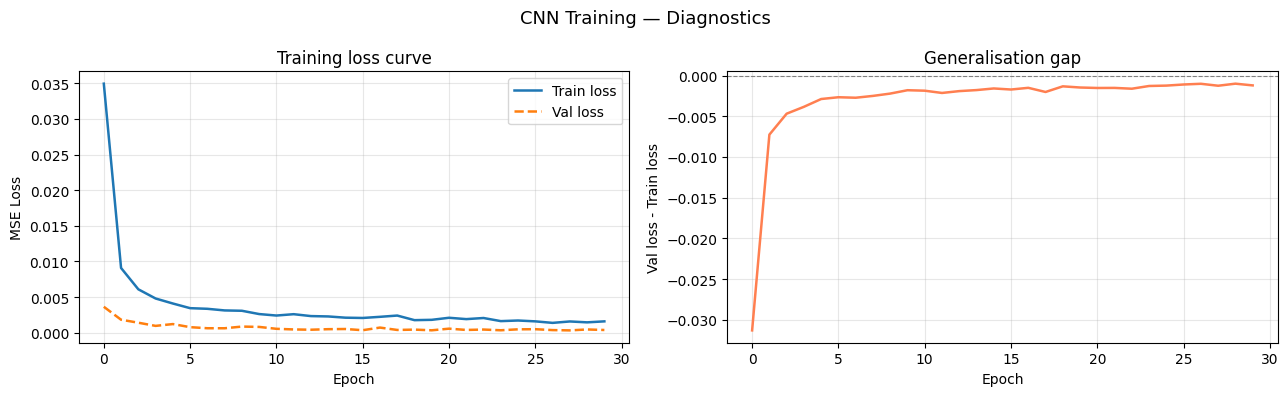

Saved training_loss.png


In [ ]:
#training loss curve plot 

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Loss over epochs
axes[0].plot(history["train_loss"], label="Train loss", linewidth=1.8)
axes[0].plot(history["val_loss"],   label="Val loss",   linewidth=1.8, linestyle="--")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training loss curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gap (overfitting diagnostic)
gap = np.array(history["val_loss"]) - np.array(history["train_loss"])
axes[1].plot(gap, color="coral", linewidth=1.8)
axes[1].axhline(0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Val loss - Train loss")
axes[1].set_title("Generalisation gap")
axes[1].grid(alpha=0.3)

plt.suptitle("CNN Training — Diagnostics", fontsize=13)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=120)
plt.show()
print("Saved training_loss.png")

In [ ]:
# Load best model and verify inference 

best_model = EnhancementCNN()
best_model.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
best_model.eval()

test_vec = torch.randn(1, 260)
params   = best_model.predict_params(test_vec)

print("Best model loaded successfully.")
print("Sample prediction (physical units):")
for k, v in params.items():
    print(f"  {k:22s}: {v[0]:.4f}")

Best model loaded successfully.
Sample prediction (physical units):
  brightness_factor     : 1.2754
  contrast_factor       : 0.5000
  gamma                 : 2.5000


In [ ]:
#Save trainer helper function to disk 

loader_code = '''
import torch
from cnn_model import EnhancementCNN
from config import Config

def load_model(path=Config.MODEL_SAVE_PATH):
    """Load a saved model from disk."""
    model = EnhancementCNN()
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    return model
'''

with open("cnn_trainer.py", "w") as f:
    f.write(loader_code)

print("cnn_trainer.py (load_model helper) written to disk.")

cnn_trainer.py (load_model helper) written to disk.
